In [32]:
import matplotlib.pyplot as plt
import pandas as pd
df =pd.read_csv('sales_data.csv')


   Product_ID   Sale_Date Sales_Rep Region  Sales_Amount  Quantity_Sold  \
0        1052  2023-02-03       Bob  North       5053.97             18   
1        1093  2023-04-21       Bob   West       4384.02             17   
2        1015  2023-09-21     David  South       4631.23             30   
3        1072  2023-08-24       Bob  South       2167.94             39   
4        1061  2023-03-24   Charlie   East       3750.20             13   

  Product_Category  Unit_Cost  Unit_Price Customer_Type  Discount  \
0        Furniture     152.75      267.22     Returning      0.09   
1        Furniture    3816.39     4209.44     Returning      0.11   
2             Food     261.56      371.40     Returning      0.20   
3         Clothing    4330.03     4467.75           New      0.02   
4      Electronics     637.37      692.71           New      0.08   

  Payment_Method Sales_Channel Region_and_Sales_Rep  
0           Cash        Online            North-Bob  
1           Cash        Re

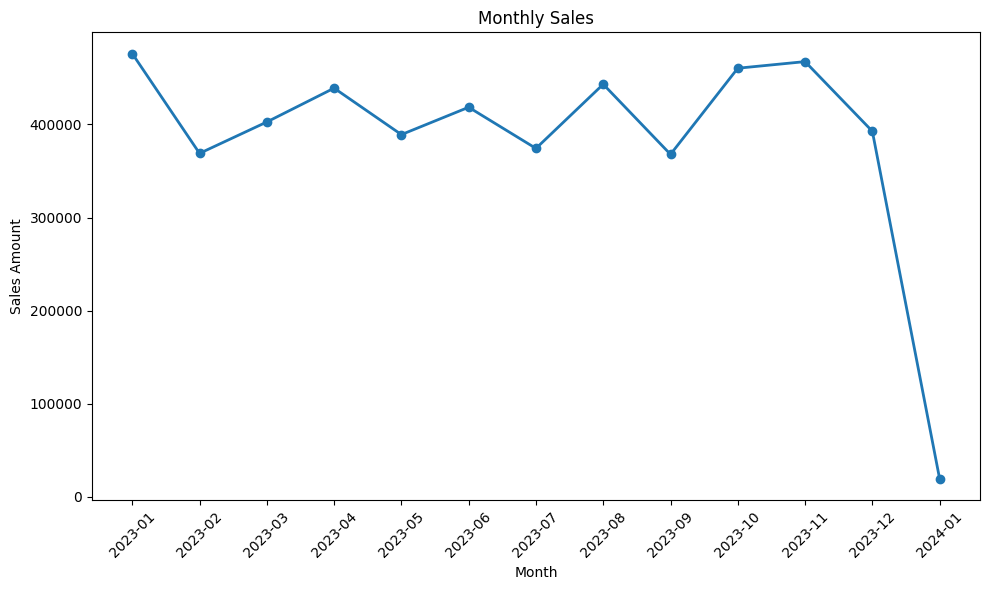

In [41]:
# prepare data
x = pd.to_datetime(df['Sale_Date'])
y = df.groupby(df['Sale_Date'].dt.to_period('M'))['Sales_Amount'].sum()

# plot monthly totals
plt.figure(figsize=(10,6))
plt.plot(y.index.astype(str), y.values, marker='o', linewidth=2)
plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

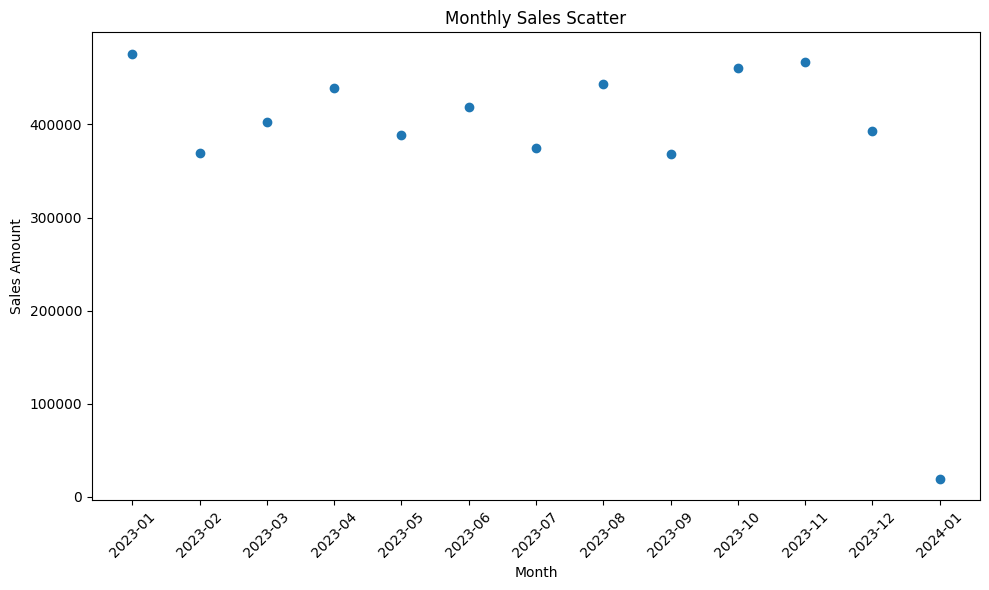

In [43]:
# scatter of monthly sales
plt.figure(figsize=(10,6))
plt.scatter(y.index.astype(str), y.values)
plt.title('Monthly Sales Scatter')
plt.xlabel('Month')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

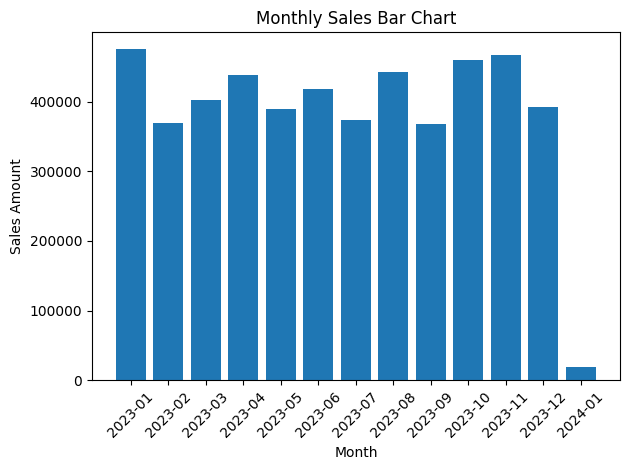

In [44]:
plt.bar(y.index.astype(str), y.values)
plt.title('Monthly Sales Bar Chart')
plt.xlabel('Month')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

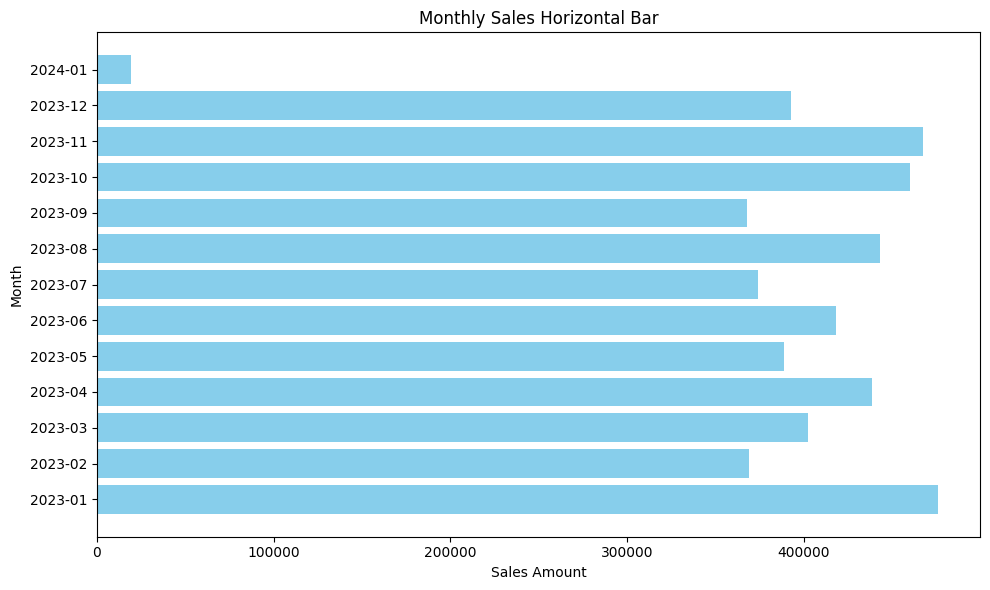

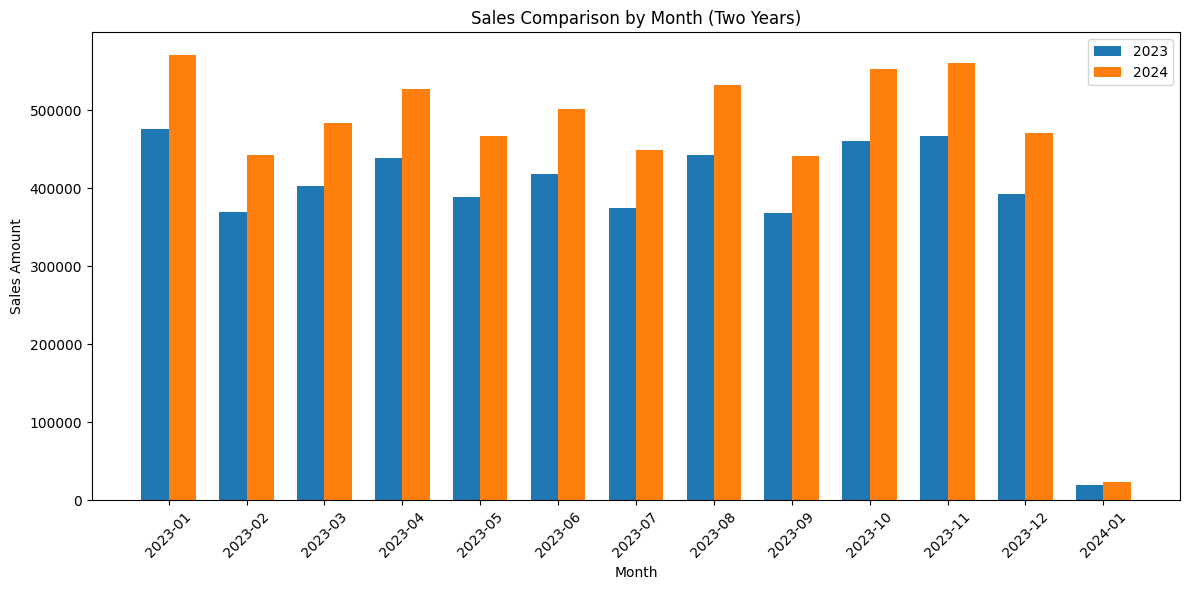

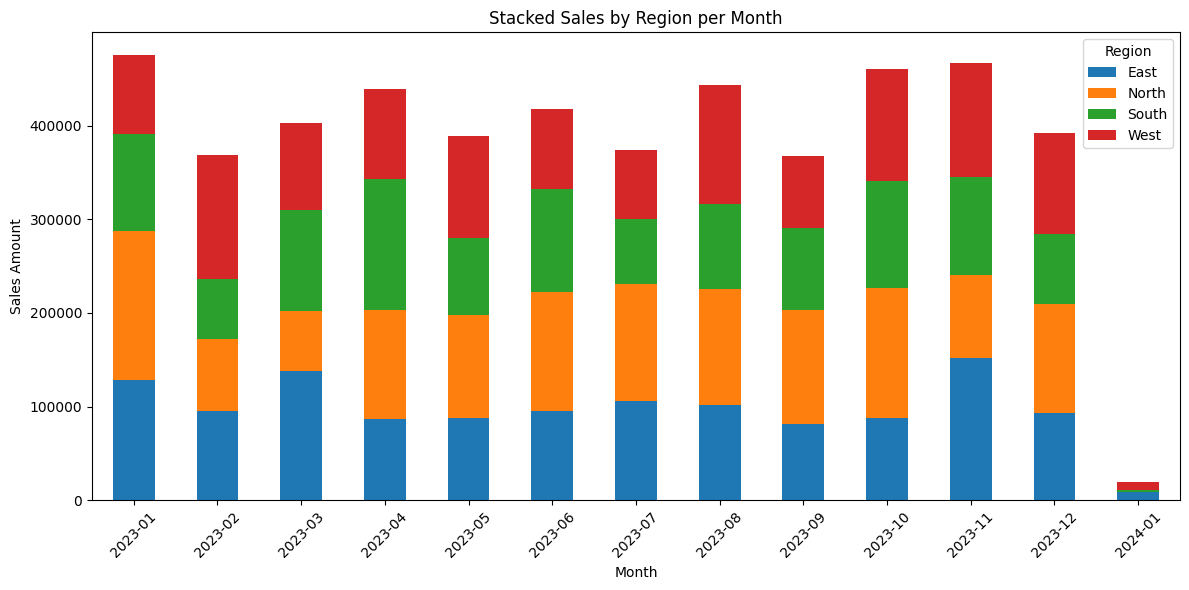

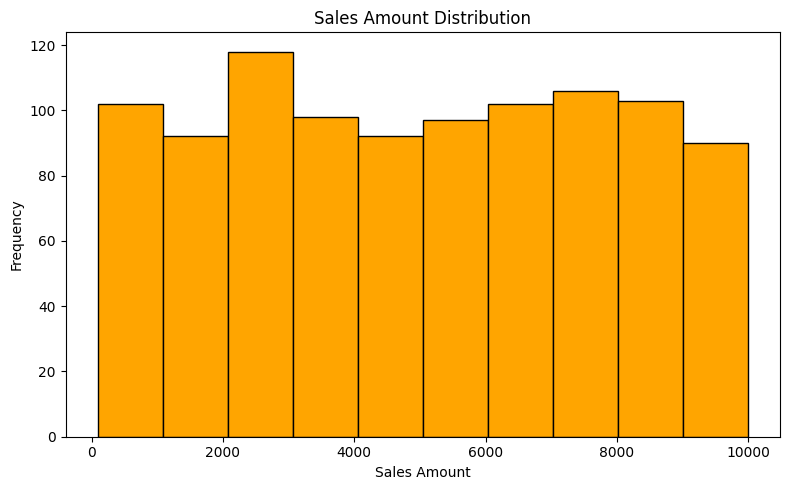

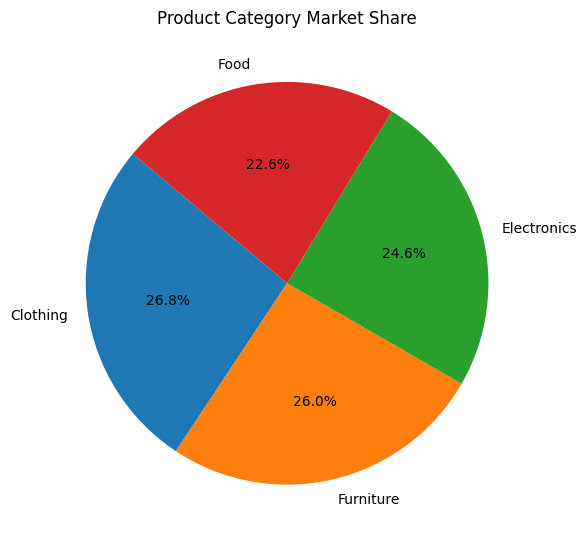

In [45]:
# horizontal bar chart of monthly sales
plt.figure(figsize=(10,6))
plt.barh(y.index.astype(str), y.values, color='skyblue')
plt.title('Monthly Sales Horizontal Bar')
plt.xlabel('Sales Amount')
plt.ylabel('Month')
plt.tight_layout()
plt.show()

# multiple bar plot comparing two years (simulated second year)
year1 = y.copy()
year2 = y * 1.2  # assume 20% growth
months = y.index.astype(str)

x_pos = range(len(months))
width = 0.35
plt.figure(figsize=(12,6))
plt.bar([p - width/2 for p in x_pos], year1.values, width=width, label='2023')
plt.bar([p + width/2 for p in x_pos], year2.values, width=width, label='2024')
plt.xticks(x_pos, months, rotation=45)
plt.title('Sales Comparison by Month (Two Years)')
plt.xlabel('Month')
plt.ylabel('Sales Amount')
plt.legend()
plt.tight_layout()
plt.show()

# stacked bar chart of sales by region per month
region_month = df.copy()
region_month['Month'] = pd.to_datetime(region_month['Sale_Date']).dt.to_period('M')
stacked = region_month.groupby(['Month','Region'])['Sales_Amount'].sum().unstack(fill_value=0)

stacked.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Stacked Sales by Region per Month')
plt.xlabel('Month')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.legend(title='Region')
plt.tight_layout()
plt.show()

# histogram of sales amount distribution
plt.figure(figsize=(8,5))
plt.hist(df['Sales_Amount'], bins=10, color='orange', edgecolor='black')
plt.title('Sales Amount Distribution')
plt.xlabel('Sales Amount')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# pie chart of product category share
category_share = df['Product_Category'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(category_share.values, labels=category_share.index, autopct='%1.1f%%', startangle=140)
plt.title('Product Category Market Share')
plt.tight_layout()
plt.show()